# Soil moisture antecedent

1. Compute the 30-day rolling average for each day of each year
2. Use those values to get the daily normal, free of noise
3. Compute the 5-day trailing average for the years 2015-2024
4. Compute the anomaly as the ratio of the 5-day trailing average to the daily normal
5. Apply a transformation, e.g. a logistic normalizing function

### I. 30-day rolling average

In [9]:
from turtledemo.chaos import plot

import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt


from jupyter_core.troubleshoot import get_data

In [ ]:
# GEE CODE, to be run in google colab to download the data
"""
30-Day Rolling Average Soil Moisture Climatology per Subdistrict
----------------------------------------------------------------
Dataset : ECMWF/ERA5_LAND/DAILY_AGGR
Band    : volumetric_soil_water_layer_1  (m³/m³, layer 1)
Period  : 1994-01-01 → 2024-12-31
Output  : One row per subdistrict, one column per DOY (1–366).
          Each cell = mean of all daily values within ±15 days of
          that DOY across all years (i.e. a 30-day centred window).

Strategy
--------
Instead of trying to do the rolling window inside GEE (complex),
we export the raw daily mean per subdistrict for the full 30-year
period and compute the climatology locally in pandas.  This avoids
GEE memory limits and gives you full control over the window logic.

Step 1  → export_raw_daily()  : submits one GEE export task per year
Step 2  → compute_climatology(): run locally once all CSVs are downloaded
"""

"""
import ee
import pandas as pd
import numpy as np
import os
import glob

# ── GEE setup ─────────────────────────────────────────────────────────────────
ee.Authenticate()
ee.Initialize(project='aqui-460614')

ASSET_PATH      = "projects/aqui-460614/assets/Sub-district_Boundary"
DISTRICT_COL    = "SUB_DIST"
DRIVE_FOLDER    = "ERA5_SoilMoisture_Raw"
START_YEAR      = 1994
END_YEAR        = 2024
SCALE           = 11132   # ~ERA5-Land native resolution in metres


# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 – Export raw daily soil moisture for each year
# ══════════════════════════════════════════════════════════════════════════════

def export_raw_daily(year: int):

    #Exports a wide CSV for `year`:
    #  columns = subdistrict attributes + one column per day (YYYY_MM_DD)
    #  values  = mean volumetric_soil_water_layer_1 (m³/m³) per subdistrict

    subdistricts = ee.FeatureCollection(ASSET_PATH)
    subdistricts_simple = subdistricts.map(lambda f: f.simplify(maxError=100))

    col = (
        ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
        .filterDate(f"{year}-01-01", f"{year + 1}-01-01")
        .select("volumetric_soil_water_layer_1")
    )

    def rename_band(img):
        date_str = img.date().format("YYYY_MM_DD")
        return img.rename(date_str)

    multi_band = col.map(rename_band).toBands()

    stats = multi_band.reduceRegions(
        collection=subdistricts_simple,
        reducer=ee.Reducer.mean(),
        scale=SCALE,
    )

    task = ee.batch.Export.table.toDrive(
        collection=stats,
        description=f"SM_Raw_Daily_{year}",
        folder=DRIVE_FOLDER,
        fileFormat="CSV",
    )
    task.start()
    print(f"  ✓ Submitted raw daily export for {year}")


print("=== Submitting GEE export tasks (Step 1) ===")
for y in range(START_YEAR, END_YEAR + 1):
    export_raw_daily(y)
print("All tasks submitted.  Download the CSVs from Google Drive, then run Step 2.")

"""

In [13]:
import re
import glob
import os
import numpy as np
import pandas as pd

_DATE_COL_RE = re.compile(r"^\d{8}.*_(\d+)$")
SUBDISTRICT_COL = "SUB_DIST"  # ← set this

def make_data(csv_folder: str) -> pd.DataFrame:
    files = sorted(glob.glob(os.path.join(csv_folder, "SM_Raw_Daily_*.csv")))
    if not files:
        raise FileNotFoundError(f"No CSVs found in {csv_folder}")

    frames = []
    for f in files:
        print(f"Processing: {f}")
        df = pd.read_csv(f, low_memory=False)

        date_cols = [c for c in df.columns if _DATE_COL_RE.match(str(c))]
        id_cols   = [c for c in df.columns if c not in date_cols]

        melted = df.melt(id_vars=id_cols, value_vars=date_cols,
                         var_name="date_str", value_name="sm")

        # ── Parse and extract only what we need, then drop heavy columns
        melted["doy"] = melted["date_str"].str.rsplit("_", n=1).str[-1].astype(int)
        melted = melted[[SUBDISTRICT_COL, "doy", "sm"]]  # drop everything else

        # ── Downcast sm to float32 to halve memory usage
        melted["sm"] = melted["sm"].astype("float32")

        frames.append(melted)

    long = pd.concat(frames, ignore_index=True)
    return long  # ← was missing!


def compute_climatology(data: pd.DataFrame, output_csv: str, window: int = 30) -> pd.DataFrame:
    half = window // 2
    long = data  # already has [SUBDISTRICT_COL, doy, sm]

    results = []
    subdistrict_ids = long[SUBDISTRICT_COL].unique()
    print(f"Computing climatology for {len(subdistrict_ids)} subdistricts...")

    for i, sd in enumerate(subdistrict_ids, 1):
        sd_df = long[long[SUBDISTRICT_COL] == sd]
        doy_vals = sd_df["doy"].values
        sm_vals  = sd_df["sm"].values
        row = {SUBDISTRICT_COL: sd}

        for doy in range(1, 367):
            low, high = doy - half, doy + half

            if low < 1:
                mask = (doy_vals >= (365 + low)) | (doy_vals <= high)
            elif high > 365:
                mask = (doy_vals >= low) | (doy_vals <= (high - 365))
            else:
                mask = (doy_vals >= low) & (doy_vals <= high)

            vals = sm_vals[mask]
            vals = vals[~np.isnan(vals)]
            row[f"DOY_{doy:03d}"] = vals.mean() if len(vals) > 0 else np.nan

        results.append(row)

        if i % 10 == 0:
            print(f"  [{i}/{len(subdistrict_ids)}] districts processed...")

    print(f"Done — {len(subdistrict_ids)} districts total.")

    clim = pd.DataFrame(results)
    clim.to_csv(output_csv, index=False)
    print(f"Saved → {output_csv}  ({len(clim)} subdistricts)")
    return clim


In [16]:
# Run
#sm_data2 = make_data(csv_folder="/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Data/ERA5 LAND sm")
print(f"Loaded {len(sm_data2):,} rows, memory: {sm_data2.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loaded 75,490,441 rows, memory: 5249.5 MB


In [21]:
sm_data2['SUB_DIST'].nunique()

6418

In [2]:
# Check what days actually exist in the melted data
sm_data = sm_data2
print("Min DOY in raw data:", sm_data["doy"].min())
print("Max DOY in raw data:", sm_data["doy"].max())

NameError: name 'sm_data2' is not defined

In [3]:
# THIS TAKES LONG (you might need ot sleep on it)
clim = compute_climatology(sm_data, output_csv="/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/antecedent soil moisture/climatology_30d_v2.csv")

NameError: name 'compute_climatology' is not defined

In [22]:
clim_30 = pd.read_csv("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/antecedent soil moisture/climatology_30d_v2.csv")

In [24]:
clim_30['SUB_DIST'].nunique()

6418

In [86]:
print(clim_30.head())

        SUB_DIST   DOY_001   DOY_002   DOY_003   DOY_004   DOY_005   DOY_006  \
0    CAR NICOBAR  0.351942  0.350084  0.348134  0.346070  0.344057  0.342057   
1  GREAT NICOBAR  0.346309  0.344641  0.342735  0.340525  0.338350  0.336134   
2       NANCOWRY  0.277932  0.275771  0.273430  0.270875  0.268314  0.265722   
3       DIGLIPUR  0.193746  0.191593  0.189494  0.187454  0.185395  0.183338   
4     MAYABUNDER  0.222443  0.219832  0.217283  0.214850  0.212450  0.209989   

    DOY_007   DOY_008   DOY_009  ...   DOY_357   DOY_358   DOY_359   DOY_360  \
0  0.340022  0.338037  0.336038  ...  0.365740  0.364084  0.362562  0.361161   
1  0.333771  0.331462  0.329229  ...  0.359046  0.357637  0.356136  0.354841   
2  0.263069  0.260552  0.258149  ...  0.294219  0.292425  0.290608  0.289000   
3  0.181350  0.179377  0.177505  ...  0.219312  0.216212  0.213058  0.209907   
4  0.207617  0.205295  0.203050  ...  0.251468  0.247999  0.244522  0.241036   

    DOY_361   DOY_362   DOY_363   DOY_

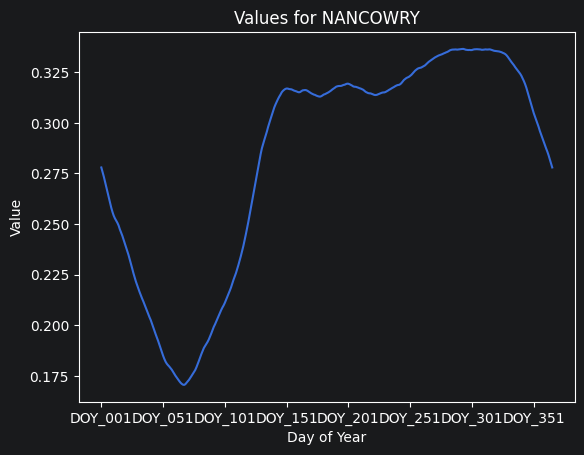

In [87]:
row = clim_30[clim_30['SUB_DIST'] == 'NANCOWRY']
row.drop(columns=['SUB_DIST']).squeeze().plot()
plt.title('Values for NANCOWRY')
plt.xlabel('Day of Year')
plt.ylabel('Value')
plt.show()

### II. Daily normal

Simply take the average of all the averages. Get one value per day of the year.

### III. 5-day trailing average

In [8]:
import pandas as pd
import os
import glob

# ── Setup ─────────────────────────────────────────────────────────────────
RAW_CSV_DIR  = "/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Data/ERA5 LAND sm"
OUTPUT_DIR   = "/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/antecedent soil moisture"
DISTRICT_COL = "SUB_DIST"
START_YEAR   = 2015
END_YEAR     = 2024

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [47]:
print("=== Starting Local 5-Day Trailing Average Calculation ===")

# 1. Load data from 2014 to 2024
# We need 2014 to provide the trailing 5 days for the start of 2015.
dfs = []
for y in range(START_YEAR - 1, END_YEAR + 1):
    file_path = os.path.join(RAW_CSV_DIR, f"SM_Raw_Daily_{y}.csv")

    if not os.path.exists(file_path):
        print(f"⚠️ Warning: Missing {file_path}. Calculation might have gaps.")
        continue

    df = pd.read_csv(file_path)

    # Filter to keep only the district ID and the date columns (YYYY_MM_DD)
    # GEE often adds metadata columns (.geo, system:index), which we drop here.
    cols_to_keep = [c for c in df.columns if c == DISTRICT_COL or c.startswith(("19", "20"))]
    df = df[cols_to_keep]
    # Set the subdistrict as the index so we only have date columns left
    df.set_index(DISTRICT_COL, inplace=True)
    dfs.append(df)

=== Starting Local 5-Day Trailing Average Calculation ===


/var/folders/q2/z68hsy6j50x95qjg_gzyl4r00000gn/T/ipykernel_3064/1303980032.py:13: DtypeWarning: Columns (0: DIST_LGD, 1: REMARKS, 2: SUBDIS_LGD) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [48]:
# 2. Combine all years horizontally
print("Merging yearly data...")
combined_df = pd.concat(dfs, axis=1)

Merging yearly data...


In [60]:
# 3. Transpose so Dates are rows and Subdistricts are columns (easier for time-series math)
ts_df = combined_df.T
print(ts_df.head(3))
# Convert the YYYY_MM_DD string index to actual datetime objects and sort them
# ts_df['doy'] = ts_df.index.str.split('_').str[-1].astype(int)
ts_df.index = pd.to_datetime(ts_df.index.str[:8], format='%Y%m%d')
ts_df.sort_index(inplace=True)

print(ts_df.head(3))


SUB_DIST             CAR NICOBAR  GREAT NICOBAR  NANCOWRY  DIGLIPUR  \
20140101_2014_01_01     0.322733       0.413438  0.354847  0.163442   
20140102_2014_01_02     0.354815       0.416183  0.366150  0.159761   
20140103_2014_01_03     0.368167       0.411500  0.354505  0.156653   

SUB_DIST             MAYABUNDER    RANGAT  FERRARGUNJ  LITTLE ANDAMAN  \
20140101_2014_01_01    0.188235  0.193871    0.150872        0.232159   
20140102_2014_01_02    0.183736  0.188601    0.146178        0.230812   
20140103_2014_01_03    0.179781  0.183994    0.142077        0.227825   

SUB_DIST             PORT BLAIR  GOSSAIGAON CIRCLE  ...   NANPARA  PAYAGPUR  \
20140101_2014_01_01    0.074994           0.204799  ...  0.248700  0.255086   
20140102_2014_01_02    0.072121           0.201512  ...  0.236822  0.242831   
20140103_2014_01_03    0.069816           0.201972  ...  0.227382  0.232859   

SUB_DIST               BHINGA    IKAUNA  JAMUNAHA  COLONELGANJ    AMETHI  \
20140101_2014_01_01  0.228572

In [61]:
# 4. Calculate the 5-day trailing average
print("Calculating 5-day trailing average...")
# closed='left' means for Day X, it calculates the mean of X-5, X-4, X-3, X-2, X-1 (excluding X)
trailing_5d = ts_df.rolling(window=5, closed='left').mean()
# 5. Filter the dataframe to only keep our target years (2015 - 2024)
trailing_5d = trailing_5d[trailing_5d.index.year >= START_YEAR]
# 6. Transpose back (Rows = Subdistricts, Columns = Dates)
final_df = trailing_5d.T

Calculating 5-day trailing average...


In [62]:
# 7. Split back into yearly CSVs and export
for y in range(START_YEAR, END_YEAR + 1):
    # Select columns for this specific year
    cols_for_year = [c for c in final_df.columns if c.year == y]
    out_df = final_df[cols_for_year].copy()

    # Rename the datetime columns back to YYYY_MM_DD string format
    out_df.columns = [c.strftime('%Y_%m_%d') for c in out_df.columns]

    # Bring the subdistrict ID back from the index to a standard column
    out_df.reset_index(inplace=True)

    # Save
    out_path = os.path.join(OUTPUT_DIR, f"SM_5day_Trailing_{y}.csv")
    out_df.to_csv(out_path, index=False)
    print(f"  ✓ Saved {out_path}")

print("=== Processing Complete ===")

  ✓ Saved /Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/antecedent soil moisture/SM_5day_Trailing_2015.csv
  ✓ Saved /Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/antecedent soil moisture/SM_5day_Trailing_2016.csv
  ✓ Saved /Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/antecedent soil moisture/SM_5day_Trailing_2017.csv
  ✓ Saved /Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/antecedent soil moisture/SM_5day_Trailing_2018.csv
  ✓ Saved /Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/antecedent soil moisture/SM_5day_Trailing_2019.csv
  ✓ Saved /Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/antecedent soil moisture/SM_5day_Trailing_2020.csv
  ✓ Saved /Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/antecedent soil moisture/SM_5day_Trailing_2021.csv
  ✓ Saved /Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/antecedent soil moisture/SM_5day_Trailing_2022.csv


In [68]:
clim_df = pd.read_csv("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/antecedent soil moisture/climatology_30d.csv")

In [74]:
# 1. Prepare Climatology for fast lookup
# We want SUB_DIST as the index and columns to be just the integers 1-366
clim_lookup = clim_df.set_index('SUB_DIST')
# Rename 'DOY_001' -> 1, 'DOY_002' -> 2 for easier matching
clim_lookup.columns = [int(c.split('_')[-1]) for c in clim_lookup.columns]

# 2. Create a container for the new columns
# We'll work on a copy to avoid SettingWithCopy warnings
combined_df = final_df.copy()

print("Calculating Climatology and Anomalies...")

i = 0
print('Computing year: {year}'.format(year = START_YEAR))
for date_col in final_df.columns:
    i +=1
    if i % 365 == 0:
        print('Computing year: {year}'.format(year=date_col.year +1))
    # Get metadata for this specific date
    doy = date_col.dayofyear
    date_str = date_col.strftime('%Y_%m_%d')

    # Check if this DOY exists in our climatology (handles leap years)
    if doy in clim_lookup.columns:
        # A. Get the Climatology values for all subdistricts for this DOY
        # .reindex ensures we match the subdistricts in combined_df exactly
        clim_vals = clim_lookup[doy].reindex(combined_df.index)

        # B. Create the '_clim' column
        combined_df[f"{date_str}_clim"] = clim_vals

        # C. Create the '_anomaly' column (Clim - Observed)
        # combined_df[date_col] is the original observed value
        combined_df[f"{date_str}_anomaly"] = combined_df[f"{date_str}_clim"] - combined_df[date_col]

# 3. Cleanup and Export
# Rename the original datetime columns to string format
combined_df.columns = [c.strftime('%Y_%m_%d') if isinstance(c, pd.Timestamp) else c for c in combined_df.columns]

# Move SUB_DIST from index to column
combined_df.reset_index(inplace=True)

# Save as one single large file
output_file = os.path.join(OUTPUT_DIR, "SM_Full_Timeseries_with_Anomalies.csv")
combined_df.to_csv(output_file, index=False)

print(f"=== Success! Saved combined file to {output_file} ===")

Calculating Climatology and Anomalies...
Computing year: 2015


/var/folders/q2/z68hsy6j50x95qjg_gzyl4r00000gn/T/ipykernel_3064/1718350736.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df[f"{date_str}_anomaly"] = combined_df[f"{date_str}_clim"] - combined_df[date_col]
/var/folders/q2/z68hsy6j50x95qjg_gzyl4r00000gn/T/ipykernel_3064/1718350736.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df[f"{date_str}_clim"] = clim_vals


Computing year: 2016
Computing year: 2017
Computing year: 2018
Computing year: 2019
Computing year: 2020
Computing year: 2021
Computing year: 2022
Computing year: 2023
Computing year: 2024
Computing year: 2025


/var/folders/q2/z68hsy6j50x95qjg_gzyl4r00000gn/T/ipykernel_3064/1718350736.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined_df.reset_index(inplace=True)


=== Success! Saved combined file to /Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/antecedent soil moisture/SM_Full_Timeseries_with_Anomalies.csv ===


In [77]:
# 1. Select only the SUB_DIST and the columns ending in '_anomaly'
anomaly_cols = [c for c in combined_df.columns if str(c).endswith('_anomaly')]
export_df = combined_df[['SUB_DIST'] + anomaly_cols].copy()

# 2. Clean the column names: "2023_01_04_anomaly" -> "2023_01_04"
# This makes the Excel sheet much easier to read
export_df.columns = [c.replace('_anomaly', '') if '_anomaly' in str(c) else c for c in export_df.columns]

# 3. Save

output_file = os.path.join(OUTPUT_DIR, "SM_Soil_Moisture_Anomalies.csv")
export_df.to_csv(output_file, index=False)

print(f"✓ Deviations-only csv saved: {output_file}")

✓ Deviations-only csv saved: /Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/antecedent soil moisture/SM_Soil_Moisture_Anomalies.csv


In [26]:
deviations = pd.read_csv("/Users/ninabilirossi/Desktop/MSC THESIS/Data works/Code/Outputs/antecedent soil moisture/SM_Soil_Moisture_Anomalies.csv")

In [27]:
deviations['SUB_DIST'].nunique()

6418